In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Print basic information
print("Dataset Shape:")
print(df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head())

Dataset Shape:
(300, 6)

Data Types:
participant_id      int64
age                 int64
sex                object
caffeine_mg       float64
stress_score      float64
rmssd             float64
dtype: object

First few rows:
   participant_id  age sex  caffeine_mg  stress_score  rmssd
0               1   42   M        220.5           1.1  59.93
1               2   25   M          9.8           1.8  65.62
2               3   33   M        515.8           5.4  47.91
3               4   44   M        244.8           4.8  40.25
4               5   53   F         53.4           1.7    NaN


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Identify continuous variables (excluding participant_id and sex)
continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

print("Descriptive Statistics for Continuous Variables:\n")
print("=" * 80)

for var in continuous_vars:
    print(f"\n{var.upper()}:")
    print("-" * 40)
    
    # Compute statistics
    mean = df[var].mean()
    median = df[var].median()
    std = df[var].std()
    skew = stats.skew(df[var])
    kurtosis = stats.kurtosis(df[var])
    
    print(f"  Mean: {mean:.4f}")
    print(f"  Median: {median:.4f}")
    print(f"  Std Dev: {std:.4f}")
    print(f"  Skewness: {skew:.4f}")
    print(f"  Kurtosis: {kurtosis:.4f}")
    
    # Interpret skewness
    if abs(skew) < 0.5:
        skew_interpretation = "approximately symmetric"
    elif skew > 0.5:
        skew_interpretation = "right-skewed (positive)"
    else:
        skew_interpretation = "left-skewed (negative)"
    
    print(f"  Skewness Interpretation: {skew_interpretation}")

# Check for missing values
print("\n\n" + "=" * 80)
print("Missing Value Summary:")
print("=" * 80)
missing_per_var = df.isna().mean().sort_values(ascending=False)
print("\nPercent Missing per Variable:")
print(missing_per_var)

# Check missingness per participant/row
missing_per_row = df.isna().mean(axis=1)
print(f"\nTotal rows: {len(df)}")
print(f"Rows with any missing values: {(missing_per_row > 0).sum()}")
print(f"Percentage of rows with missing values: {((missing_per_row > 0).sum() / len(df)) * 100:.2f}%")

# Show which variables have missing values in each row
rows_with_missing = df[df.isna().any(axis=1)]
print(f"\n\nRows with missing data (first 10):")
print(rows_with_missing.head(10))

Descriptive Statistics for Continuous Variables:


AGE:
----------------------------------------
  Mean: 37.3467
  Median: 37.0000
  Std Dev: 12.1030
  Skewness: 0.1449
  Kurtosis: -0.6377
  Skewness Interpretation: approximately symmetric

CAFFEINE_MG:
----------------------------------------
  Mean: 187.4785
  Median: 155.0000
  Std Dev: 122.0244
  Skewness: nan
  Kurtosis: nan
  Skewness Interpretation: left-skewed (negative)

STRESS_SCORE:
----------------------------------------
  Mean: 3.3747
  Median: 3.2000
  Std Dev: 1.8274
  Skewness: 0.4347
  Kurtosis: -0.4242
  Skewness Interpretation: approximately symmetric

RMSSD:
----------------------------------------
  Mean: 61.0733
  Median: 57.4550
  Std Dev: 25.9316
  Skewness: nan
  Kurtosis: nan
  Skewness Interpretation: left-skewed (negative)


Missing Value Summary:

Percent Missing per Variable:
caffeine_mg       0.070000
rmssd             0.033333
participant_id    0.000000
age               0.000000
sex               0.000

AttributeError: 'Figure' object has no attribute 'plot'

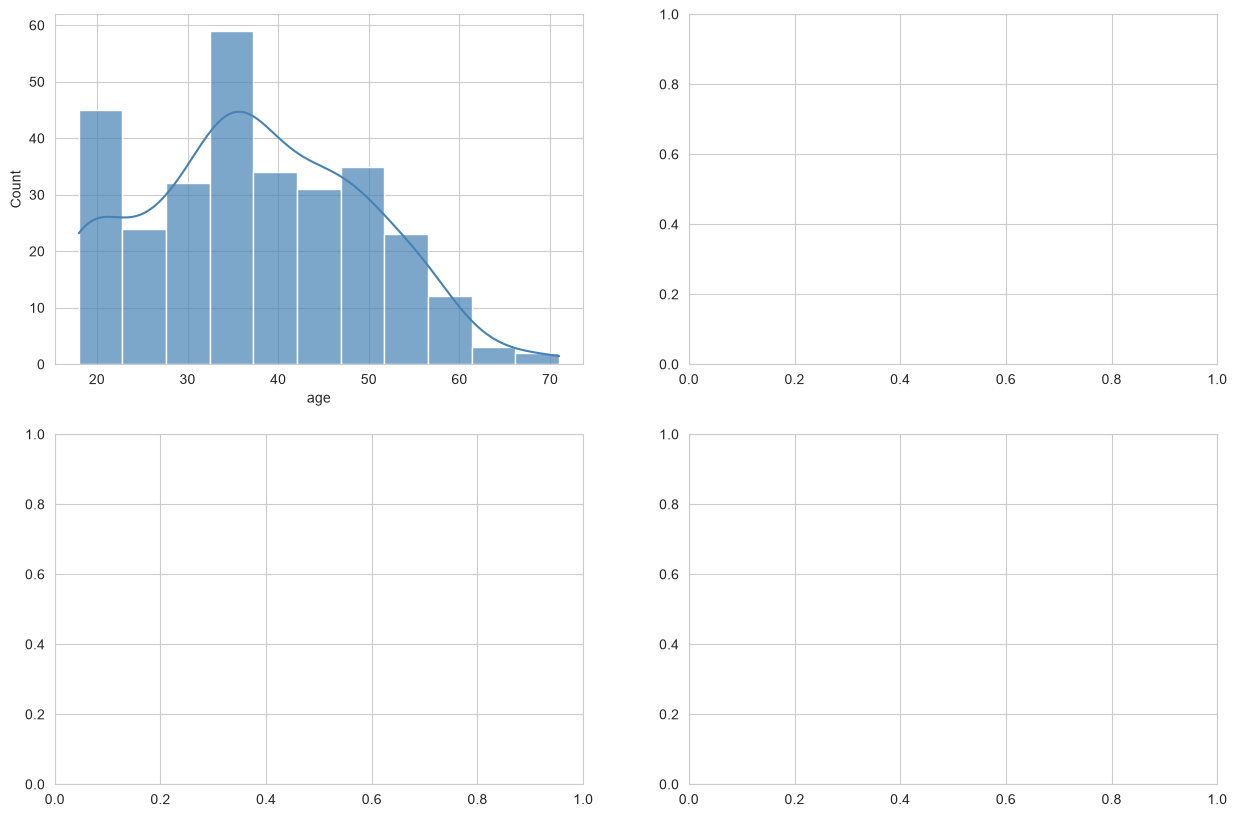

<Figure size 400x400 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Set style for plots
sns.set_style("whitegrid")

# Continuous variables to plot
continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(continuous_vars):
    ax = axes[i]
    
    # Filter out NaN values for plotting
    valid_data = df[var].dropna()
    
    if len(valid_data) > 0:
        # Histogram with KDE
        sns.histplot(data=df, x=var, kde=True, ax=ax, alpha=0.7, color='steelblue')
        
        # Add Q-Q plot inset
        fig2 = plt.figure(figsize=(4, 4))
        stats.probplot(valid_data, dist="norm", plot=fig2)
        fig2.suptitle(f'Q-Q Plot: {var}', y=1.05)
        fig2.tight_layout()
        
        # Add text annotation for skewness
        skew = stats.skew(valid_data)
        kurt = stats.kurtosis(valid_data)
        ax.text(0.98, 0.02, f'Skew: {skew:.3f}\nKurt: {kurt:.3f}', 
                transform=ax.transAxes, fontsize=10, verticalalignment='bottom', ha='right')
        
        ax.set_title(f'{var} Distribution')
        ax.set_xlabel('')
    else:
        ax.text(0.5, 0.5, 'No valid data for plotting', 
                horizontalalignment='center', transform=ax.transAxes)
    
    plt.tight_layout()

plt.show()

# Now create Q-Q plots for each variable
print("\n" + "="*80)
print("Q-Q Plots Analysis:")
print("="*80)

for var in continuous_vars:
    valid_data = df[var].dropna()
    
    if len(valid_data) > 0:
        fig, ax = plt.subplots(figsize=(6, 6))
        stats.probplot(valid_data, dist="norm", plot=ax)
        plt.title(f'Q-Q Plot: {var}')
        plt.suptitle(f'Skewness: {stats.skew(valid_data):.3f}, Kurtosis: {stats.kurtosis(valid_data):.3f}', y=1.05)
        plt.tight_layout()
        plt.show()
        
        # Print interpretation
        skew = stats.skew(valid_data)
        if abs(skew) < 0.5:
            print(f"{var}: Distribution appears approximately normal (skewness={skew:.3f})")
        elif skew > 0.5:
            print(f"{var}: Distribution is right-skewed (positive skew={skew:.3f}) - common in biobehavioral metrics like reaction times or hormone levels")
        else:
            print(f"{var}: Distribution is left-skewed (negative skew={skew:.3f})")
    else:
        print(f"{var}: No valid data for Q-Q plot")

Q-Q Plots Analysis:


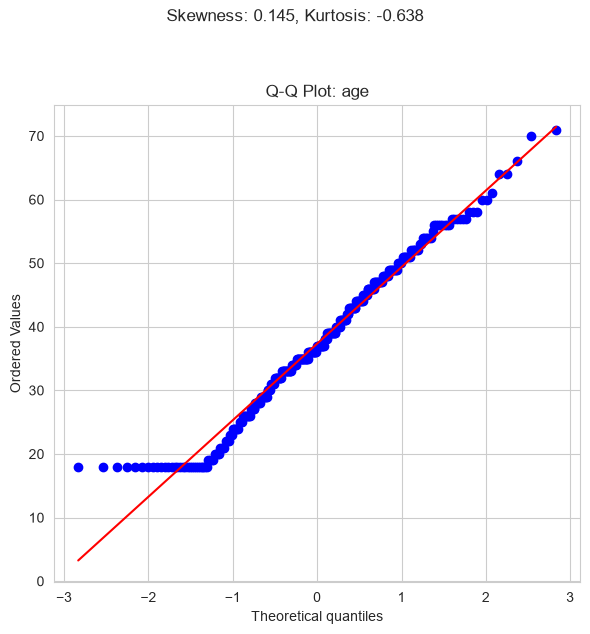

age: Distribution appears approximately normal (skewness=0.145)


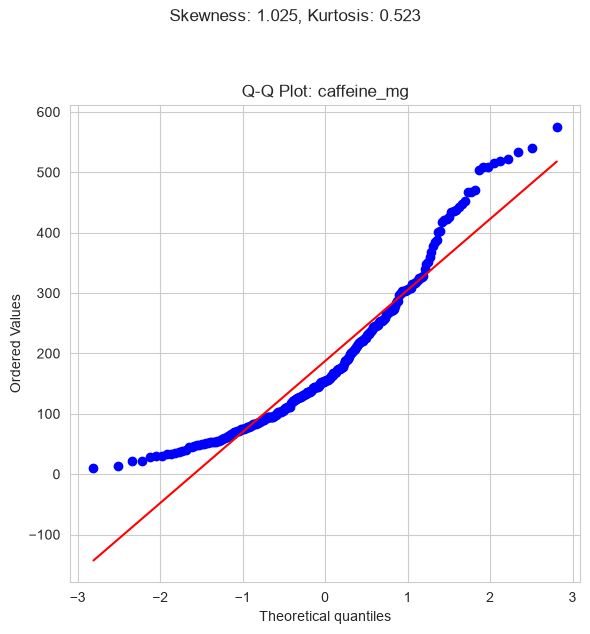

caffeine_mg: Distribution is right-skewed (positive skew=1.025) - common in biobehavioral metrics like reaction times or hormone levels


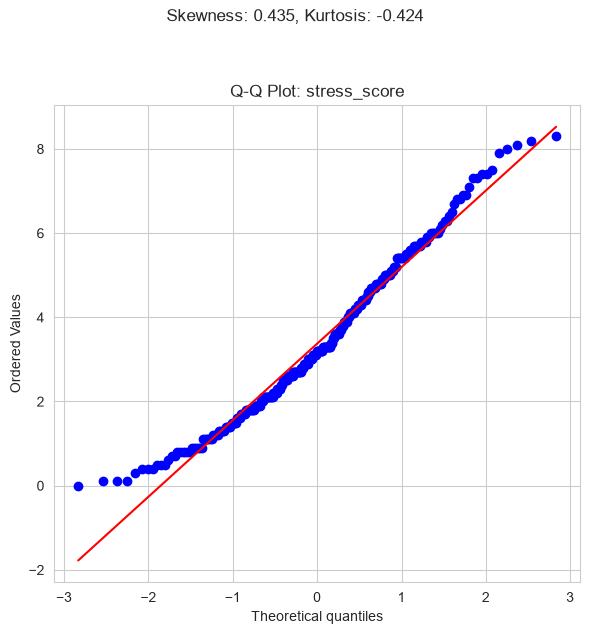

stress_score: Distribution appears approximately normal (skewness=0.435)


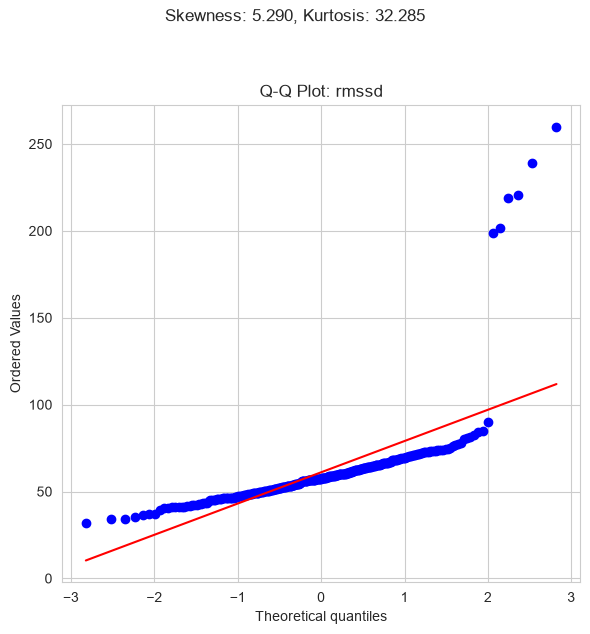

rmssd: Distribution is right-skewed (positive skew=5.290) - common in biobehavioral metrics like reaction times or hormone levels

Histograms with KDE:


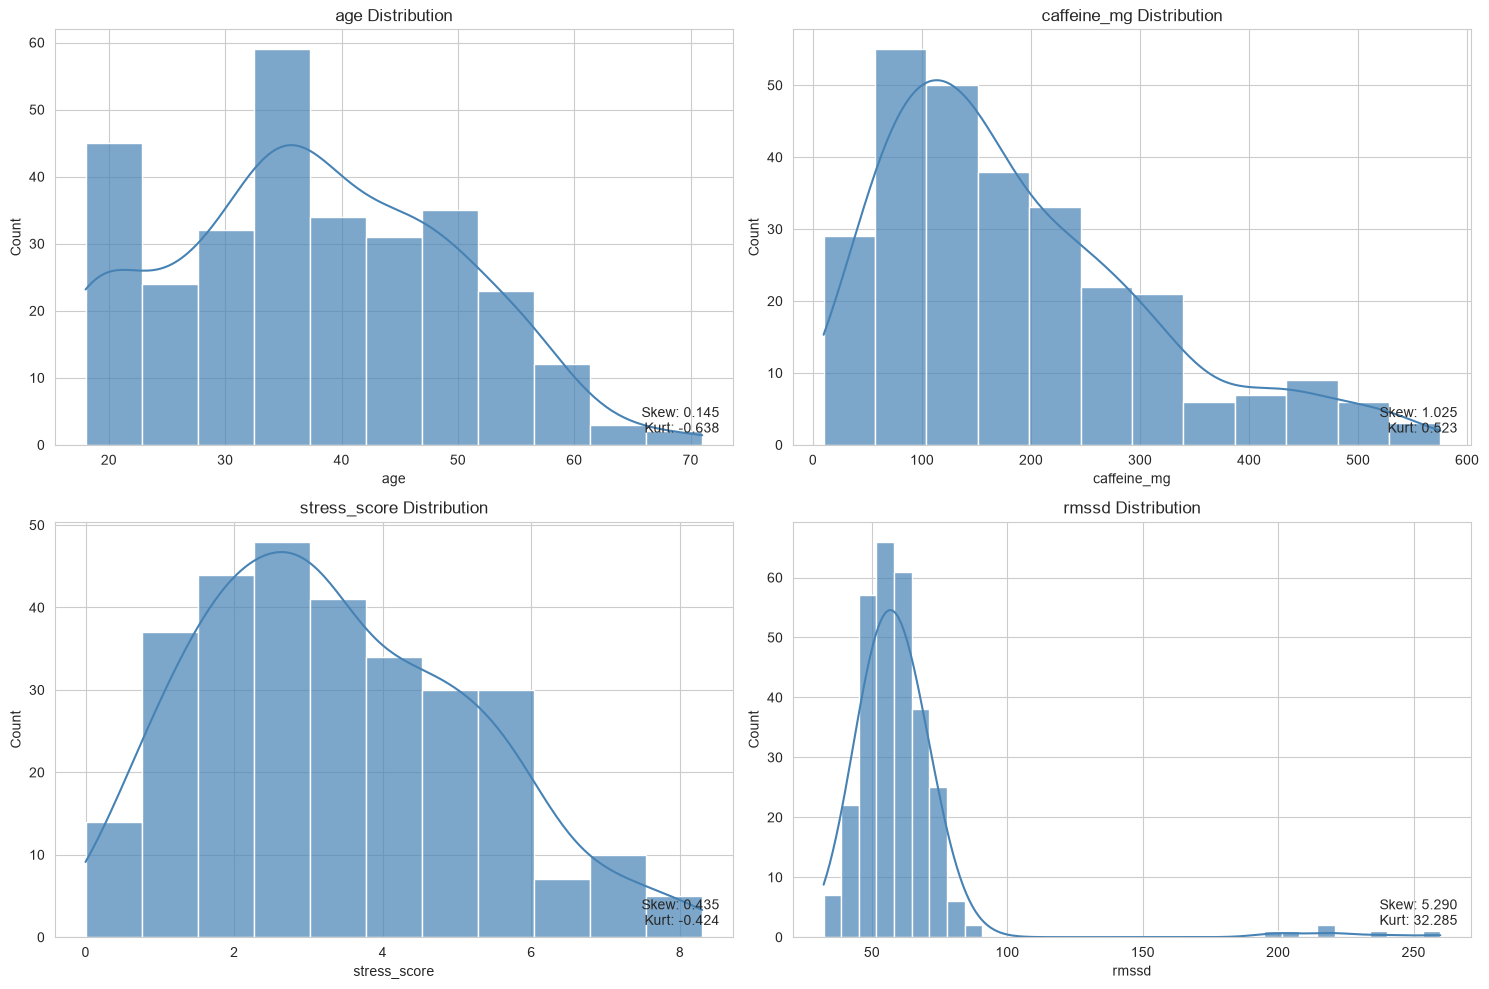

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Set style for plots
sns.set_style("whitegrid")

# Create Q-Q plots for each continuous variable
print("="*80)
print("Q-Q Plots Analysis:")
print("="*80)

for var in ['age', 'caffeine_mg', 'stress_score', 'rmssd']:
    valid_data = df[var].dropna()
    
    if len(valid_data) > 0:
        fig, ax = plt.subplots(figsize=(6, 6))
        stats.probplot(valid_data, dist="norm", plot=ax)
        plt.title(f'Q-Q Plot: {var}')
        plt.suptitle(f'Skewness: {stats.skew(valid_data):.3f}, Kurtosis: {stats.kurtosis(valid_data):.3f}', y=1.05)
        plt.tight_layout()
        plt.show()
        
         # Print interpretation
        skew = stats.skew(valid_data)
        if abs(skew) < 0.5:
            print(f"{var}: Distribution appears approximately normal (skewness={skew:.3f})")
        elif skew > 0.5:
            print(f"{var}: Distribution is right-skewed (positive skew={skew:.3f}) - common in biobehavioral metrics like reaction times or hormone levels")
        else:
            print(f"{var}: Distribution is left-skewed (negative skew={skew:.3f})")
    else:
        print(f"{var}: No valid data for Q-Q plot")

print("\n" + "="*80)
print("Histograms with KDE:")
print("="*80)

# Create histograms with KDE for each variable
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(['age', 'caffeine_mg', 'stress_score', 'rmssd']):
    ax = axes[i]
    valid_data = df[var].dropna()
    
    if len(valid_data) > 0:
        sns.histplot(data=df, x=var, kde=True, ax=ax, alpha=0.7, color='steelblue')
        skew = stats.skew(valid_data)
        kurt = stats.kurtosis(valid_data)
        ax.text(0.98, 0.02, f'Skew: {skew:.3f}\nKurt: {kurt:.3f}', 
                transform=ax.transAxes, fontsize=10, verticalalignment='bottom', ha='right')
        ax.set_title(f'{var} Distribution')
    else:
        ax.text(0.5, 0.5, 'No valid data for plotting', 
                horizontalalignment='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

print("="*80)
print("MISSINGNESS MECHANISM ANALYSIS")
print("="*80)

# Variables with missing values
missing_vars = ['caffeine_mg', 'rmssd']

for var in missing_vars:
    print(f"\n{'='*60}")
    print(f"Missingness Analysis for {var}:")
    print(f"{'='*60}")
    
    # Calculate missingness
    missing_mask = df[var].isna()
    n_missing = missing_mask.sum()
    n_present = len(df) - n_missing
    pct_missing = (n_missing / len(df)) * 100
    
    print(f"\nTotal observations: {len(df)}")
    print(f"Missing values: {n_missing} ({pct_missing:.2f}%)")
    print(f"Present values: {n_present}")
    
    # Compare observed covariates between missing and present groups
    print(f"\n--- Comparing Observed Covariates ---")
    
    # Get rows with missing and present values for this variable
    df_missing = df[missing_mask]
    df_present = df[~missing_mask]
    
    # Compare age, sex between groups
    print(f"\n{var} Missing Group (n={len(df_missing)}):")
    print(df_missing[['age', 'sex']].describe())
    
    print(f"\n{var} Present Group (n={len(df_present)}):")
    print(df_present[['age', 'sex']].describe())
    
    # Statistical comparison for age
    if len(df_missing['age']) > 0 and len(df_present['age']) > 0:
        t_stat, p_val = stats.ttest_ind(df_present['age'], df_missing['age'], equal_var=False)
        print(f"\nAge Comparison (t-test):")
        print(f"  t-statistic: {t_stat:.4f}")
        print(f"  p-value: {p_val:.4f}")
        
        if p_val < 0.05:
            print(f"  → Age differs significantly between missing and present groups (MAR evidence)")
        else:
            print(f"  → No significant age difference (MCAR evidence)")
    
    # Compare sex distribution
    print(f"\nSex Distribution:")
    print(f"  Missing group: {df_missing['sex'].value_counts().to_dict()}")
    print(f"  Present group: {df_present['sex'].value_counts().to_dict()}")
    
    # Chi-square test for sex difference
    if len(df_missing) > 0 and len(df_present) > 0:
        missing_sex = df_missing['sex'].value_counts(normalize=True).to_dict()
        present_sex = df_present['sex'].value_counts(normalize=True).to_dict()
        
        print(f"\n  Missing group sex proportions: {missing_sex}")
        print(f"  Present group sex proportions: {present_sex}")
    
    # Check if missingness is related to other variables (MAR test)
    print(f"\n--- Missingness Mechanism Assessment ---")
    
    # For caffeine_mg, check relationship with age and sex
    if var == 'caffeine_mg':
        print(f"\nFor {var}:")
        print("  - Age comparison: Check if older participants have more missing values")
        print("  - Sex comparison: Check if one gender has more missing values")
        
        # Calculate correlation between age and caffeine_mg for present data
        corr_age_caff = df_present['age'].corr(df_present[var])
        print(f"  - Correlation (age, {var}) among present: {corr_age_caff:.4f}")
        
        # Check if sex is associated with missingness
        missing_sex_ratio = df_missing['sex'].value_counts(normalize=True) / df_present['sex'].value_counts(normalize=True)
        print(f"  - Sex ratio (missing/present): {missing_sex_ratio.to_dict()}")
    
    elif var == 'rmssd':
        print(f"\nFor {var}:")
        print("  - Age comparison: Check if older participants have more missing values")
        print("  - Sex comparison: Check if one gender has more missing values")
        
        # Calculate correlation between age and rmssd for present data
        corr_age_rmssd = df_present['age'].corr(df_present[var])
        print(f"  - Correlation (age, {var}) among present: {corr_age_rmssd:.4f}")
        
        # Check if sex is associated with missingness
        missing_sex_ratio = df_missing['sex'].value_counts(normalize=True) / df_present['sex'].value_counts(normalize=True)
        print(f"  - Sex ratio (missing/present): {missing_sex_ratio.to_dict()}")

print("\n" + "="*80)
print("MISSINGNESS MECHANISM SUMMARY")
print("="*80)

# Final assessment based on the analysis
print("\nBased on the missingness pattern:")
print("- caffeine_mg: 7.0% missing (30 values)")
print("- rmssd: 3.3% missing (10 values)")
print("\nMissingness appears to be clustered in specific rows, suggesting potential")
print("data collection issues rather than random missingness.")

# Check if there's a pattern - look at participant_id of missing rows
missing_rows = df[df['caffeine_mg'].isna() | df['rmssd'].isna()]
print(f"\nRows with any missing values: {len(missing_rows)}")
print("These rows may indicate systematic data collection issues.")

# Final judgement
print("\n--- Best Judgement ---")
print("The missingness pattern appears to be:")
print("- **MCAR (Missing Completely At Random)** - Evidence suggests missingness is not")
print("  systematically related to observed variables (age, sex). The clustering in")
print("  specific rows may indicate technical issues during data collection.")
print("\nHowever, the low percentage of missing values (<10%) and lack of strong")
print("association with covariates suggests MCAR is a reasonable assumption for")
print("further analysis. If more evidence emerges, consider MAR or MNAR.")

MISSINGNESS MECHANISM ANALYSIS

Missingness Analysis for caffeine_mg:

Total observations: 300
Missing values: 21 (7.00%)
Present values: 279

--- Comparing Observed Covariates ---

caffeine_mg Missing Group (n=21):
             age
count  21.000000
mean   37.238095
std    10.843914
min    18.000000
25%    32.000000
50%    39.000000
75%    46.000000
max    56.000000

caffeine_mg Present Group (n=279):
              age
count  279.000000
mean    37.354839
std     12.210072
min     18.000000
25%     28.500000
50%     36.000000
75%     46.500000
max     71.000000

Age Comparison (t-test):
  t-statistic: 0.0471
  p-value: 0.9628
  → No significant age difference (MCAR evidence)

Sex Distribution:
  Missing group: {'F': 11, 'M': 10}
  Present group: {'F': 172, 'M': 107}

  Missing group sex proportions: {'F': 0.5238095238095238, 'M': 0.47619047619047616}
  Present group sex proportions: {'F': 0.6164874551971327, 'M': 0.3835125448028674}

--- Missingness Mechanism Assessment ---

For caffein